In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("/content/bank-full.csv", sep=";")

print("Dataset loaded successfully!")
print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Dataset loaded successfully!
Number of records: 45211
Number of features: 17


In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
rows, columns = df.shape

print("Rows:", rows)
print("Columns:", columns)

Rows: 45211
Columns: 17


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [ ]:
missing = df.isna().sum()

print("Missing values in each column:")
print(missing)

Missing values in each column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

age: 77 unique values
job: 12 unique values
marital: 3 unique values
education: 4 unique values
default: 2 unique values
balance: 7168 unique values
housing: 2 unique values
loan: 2 unique values
contact: 3 unique values
day: 31 unique values
month: 12 unique values
duration: 1573 unique values
campaign: 48 unique values
pdays: 559 unique values
previous: 41 unique values
poutcome: 4 unique values
y: 2 unique values


In [ ]:
print(df["y"].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


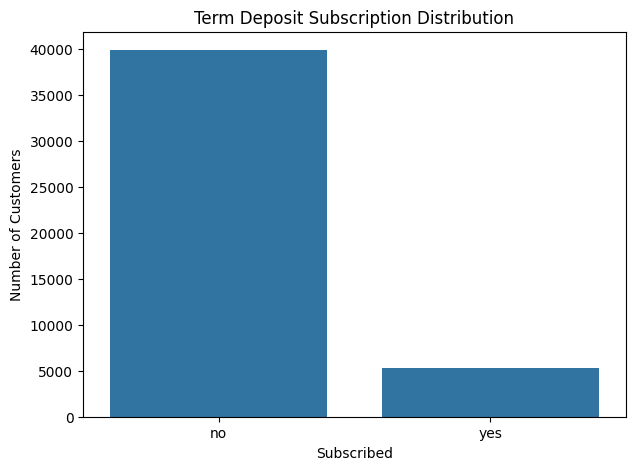

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="y")

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical features:")
print(numeric_columns)

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Categorical features:")
print(categorical_columns)

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


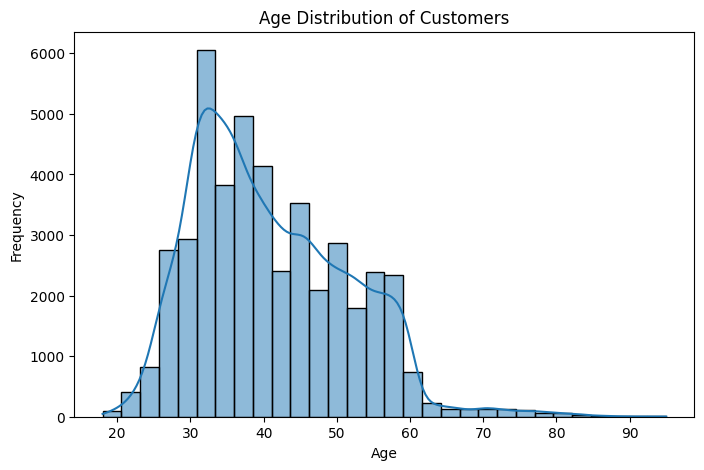

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

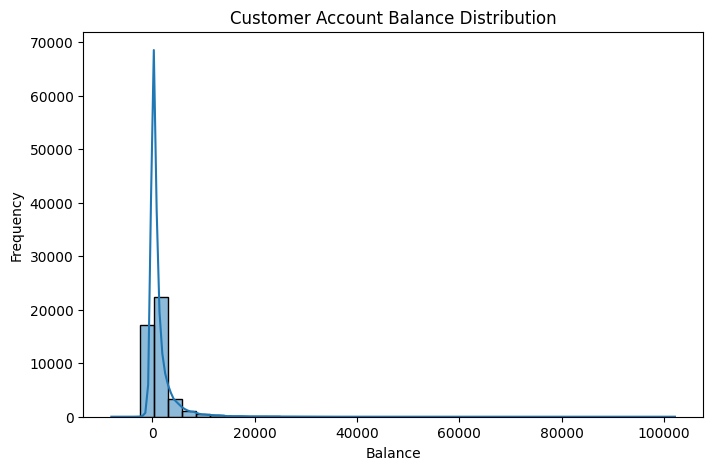

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="balance", bins=40, kde=True)

plt.title("Customer Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

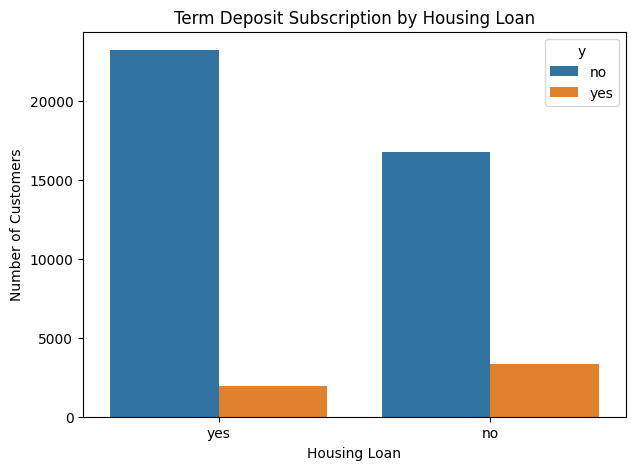

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="housing", hue="y")

plt.title("Term Deposit Subscription by Housing Loan")
plt.xlabel("Housing Loan")
plt.ylabel("Number of Customers")

plt.show()

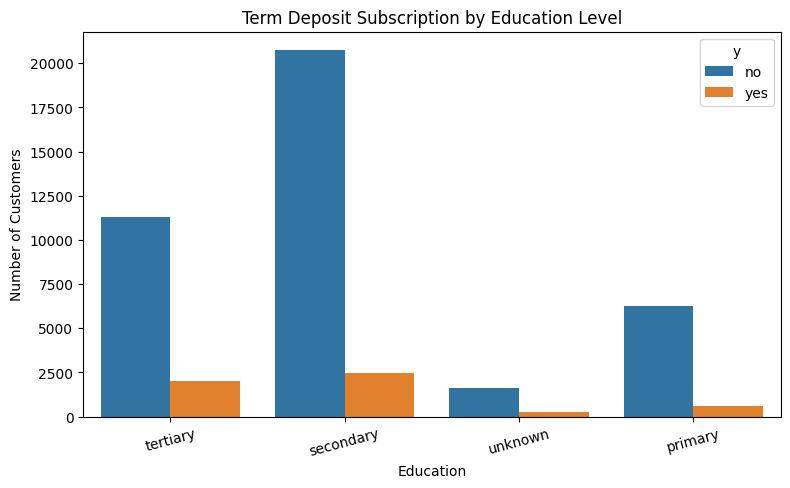

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="education", hue="y")

plt.title("Term Deposit Subscription by Education Level")
plt.xlabel("Education")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.show()

In [ ]:
X = df.drop(columns="y")
y = df["y"].map({"no": 0, "yes": 1})

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (45211, 16)
Target shape: (45211,)


In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 36168
Testing samples: 9043


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print(logistic_model)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('classifier', LogisticRegression(max_iter=1000))])


In [ ]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
train_predictions = logistic_model.predict(X_train)
test_predictions = logistic_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 0.9020
Testing Accuracy : 0.9012


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.iloc[:15].values,
    "Predicted": test_predictions[:15]
})

comparison

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


In [ ]:
report = classification_report(
    y_test,
    test_predictions,
    target_names=["No", "Yes"]
)

print(report)

              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



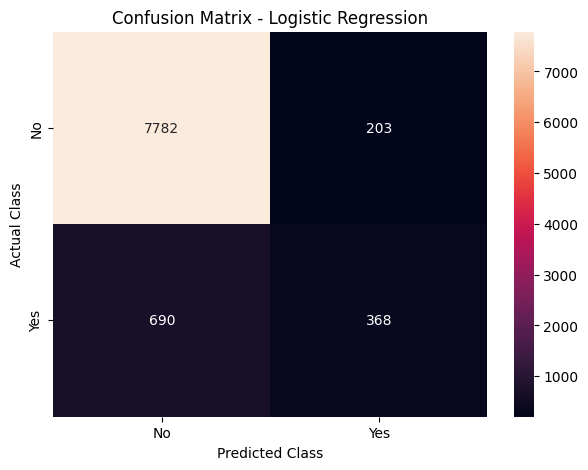

In [ ]:
matrix = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [ ]:
tn, fp, fn, tp = matrix.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 7782
False Positives: 203
False Negatives: 690
True Positives : 368


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, test_predictions)
recall = recall_score(y_test, test_predictions)
f1 = f1_score(y_test, test_predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Precision: 0.6445
Recall   : 0.3478
F1-Score : 0.4518


In [ ]:
accuracy_gap = train_accuracy - test_accuracy

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Testing accuracy : {test_accuracy:.4f}")
print(f"Accuracy gap     : {accuracy_gap:.4f}")

Training accuracy: 0.9020
Testing accuracy : 0.9012
Accuracy gap     : 0.0008


In [ ]:
feature_names = logistic_model.named_steps["preprocessing"].get_feature_names_out()

coefficients = logistic_model.named_steps["classifier"].coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table["Absolute_Impact"] = coefficient_table["Coefficient"].abs()

coefficient_table = coefficient_table.sort_values(
    "Absolute_Impact",
    ascending=False
)

coefficient_table.head(15)

,Feature,Coefficient,Absolute_Impact
49,categorical__poutcome_success,1.549282,1.549282
42,categorical__month_mar,1.457573,1.457573
39,categorical__month_jan,-1.321511,1.321511
34,categorical__contact_unknown,-1.201578,1.201578
3,numeric__duration,1.091874,1.091874
44,categorical__month_nov,-0.927599,0.927599
40,categorical__month_jul,-0.883044,0.883044
46,categorical__month_sep,0.816278,0.816278
47,categorical__poutcome_failure,-0.792804,0.792804
50,categorical__poutcome_unknown,-0.778145,0.778145


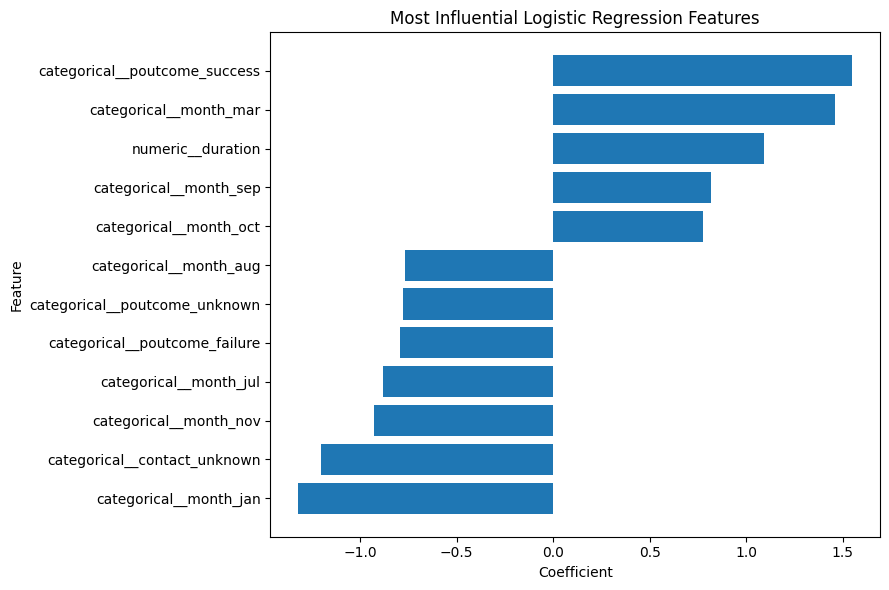

In [ ]:
top_features = coefficient_table.head(12).sort_values("Coefficient")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Most Influential Logistic Regression Features")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1
    ]
})

results

,Metric,Score
0,Training Accuracy,0.902013
1,Testing Accuracy,0.901250
2,Precision,0.644483
3,Recall,0.347826
4,F1-Score,0.451811


In [ ]:
print("MODEL FINDINGS")
print("-" * 40)
print(f"Training Accuracy : {train_accuracy:.2%}")
print(f"Testing Accuracy  : {test_accuracy:.2%}")
print(f"Precision         : {precision:.2%}")
print(f"Recall            : {recall:.2%}")
print(f"F1-Score          : {f1:.2%}")
print("-" * 40)

if train_accuracy - test_accuracy < 0.05:
    print("The training and testing accuracies are relatively close.")
else:
    print("There is a noticeable difference between training and testing accuracy.")

MODEL FINDINGS
----------------------------------------
Training Accuracy : 90.20%
Testing Accuracy  : 90.12%
Precision         : 64.45%
Recall            : 34.78%
F1-Score          : 45.18%
----------------------------------------
The training and testing accuracies are relatively close.


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

test_probabilities = logistic_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, test_probabilities)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9056


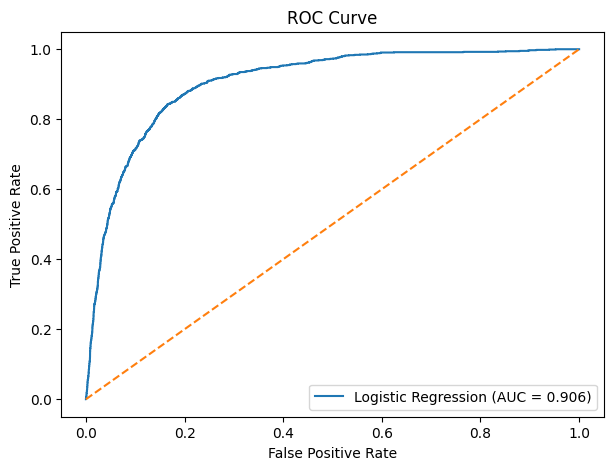

In [ ]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()